# Bank Customer Churn Analysis

## Analyze customer data to identify factors influencing churn and provide actionable insights to improve customer retention.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))


<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [3]:
df = pd.read_csv("bank_churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Data understanding
We explore the structure, data types and the basic statistics of the dataset

In [4]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Data cleaning
Handling missing values,removing unnecessary columns and fixing data types

In [5]:
#checking for duplicates
df.duplicated().sum()

#checking for missing values
df.isnull().sum()

#Dropping unnecessary columns
df.drop(['Surname'], axis = 1, inplace = True)

In [6]:

#Displaying CustomerId in float format with no decimal places
pd.options.display.float_format = '{:.0f}'.format

In [7]:
df.head()

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,619,France,Female,42,2,0,1,1,1,101349,1,1,2,DIAMOND,464
1,2,15647311,608,Spain,Female,41,1,83808,1,0,1,112543,0,1,3,DIAMOND,456
2,3,15619304,502,France,Female,42,8,159661,3,1,0,113932,1,1,3,DIAMOND,377
3,4,15701354,699,France,Female,39,1,0,2,0,0,93827,0,0,5,GOLD,350
4,5,15737888,850,Spain,Female,43,2,125511,1,1,1,79084,0,0,5,GOLD,425


In [8]:
df.rename(columns={'HasCrCard':'HasCreditCard'}, inplace=True)

In [9]:
#Age groups
df['AgeGroup']=pd.cut(df['Age'],bins=[17, 25, 40, 60, 100], labels=['18-25', '26-40','41-60', '60+'])

#Tenure groups
df['TenureGroup']=pd.cut(df['Tenure'],bins=[-1, 2, 5, 10], labels=['0-2', '3-5', '6-10'])

#Credit groups
df['CreditGroup']=pd.cut(df['CreditScore'],bins=[300, 450, 600, 900], labels=['Poor', 'Average', 'Good'])

#Balance groups
df['BalanceGroup'] = pd.cut(df['Balance'], bins=[-1, 50000, 120000, 251000], labels=['Low', 'Medium', 'High'])

#EstimatedSalary groups
df['EstimatedSalaryGroup']=pd.cut(df['EstimatedSalary'],bins=[-1, 50000, 100000, 150000], labels=['Low', 'Medium', 'High'])

#Point groups
df['PointGroup']=pd.cut(df['Point Earned'],bins=[118, 400, 700, 1001], labels=['Low', 'Medium', 'High'])

In [10]:
p = df['CreditScore'].max()
print(p)

850


In [11]:
df.head()

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,...,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup,TenureGroup,CreditGroup,BalanceGroup,EstimatedSalaryGroup,PointGroup
0,1,15634602,619,France,Female,42,2,0,1,1,...,1,2,DIAMOND,464,41-60,0-2,Good,Low,High,Medium
1,2,15647311,608,Spain,Female,41,1,83808,1,0,...,1,3,DIAMOND,456,41-60,0-2,Good,Medium,High,Medium
2,3,15619304,502,France,Female,42,8,159661,3,1,...,1,3,DIAMOND,377,41-60,6-10,Average,High,High,Low
3,4,15701354,699,France,Female,39,1,0,2,0,...,0,5,GOLD,350,26-40,0-2,Good,Low,Medium,Low
4,5,15737888,850,Spain,Female,43,2,125511,1,1,...,0,5,GOLD,425,41-60,0-2,Good,High,Medium,Medium


In [12]:
df.dtypes

RowNumber                  int64
CustomerId                 int64
CreditScore                int64
Geography                    str
Gender                       str
Age                        int64
Tenure                     int64
Balance                  float64
NumOfProducts              int64
HasCreditCard              int64
IsActiveMember             int64
EstimatedSalary          float64
Exited                     int64
Complain                   int64
Satisfaction Score         int64
Card Type                    str
Point Earned               int64
AgeGroup                category
TenureGroup             category
CreditGroup             category
BalanceGroup            category
EstimatedSalaryGroup    category
PointGroup              category
dtype: object

# Exploratory Data Analysis(EDA)


## Churn Rate by Age

In [13]:
age_group = (df.groupby('AgeGroup')['Exited'].mean() * 100).round(2)
age_group.astype(str) + '%'

AgeGroup
18-25     7.53%
26-40    11.04%
41-60    39.65%
60+      24.78%
Name: Exited, dtype: str

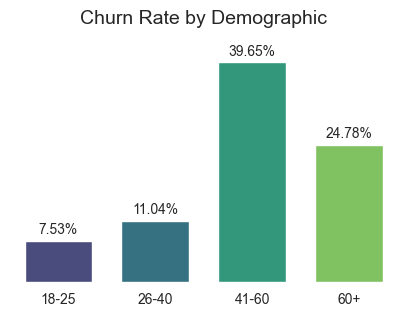

In [14]:
#Visualization
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='AgeGroup', y='Exited', data=df, hue='AgeGroup', palette='viridis', errorbar=None, dodge=False, width=0.7)

# Adding the data labels
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True) 

plt.title("Churn Rate by Demographic", fontsize=14, pad=20)
plt.show()

## Churn Rate by Gender

In [15]:
df.groupby('Gender')['Exited'].mean() * 100

Gender
Female   25
Male     16
Name: Exited, dtype: float64

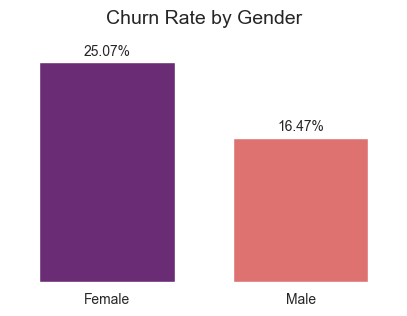

In [16]:
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='Gender', y='Exited', data=df, hue='Gender', palette='magma', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Gender", fontsize=14, pad=20)
plt.show()

## Churn Rate By Geography

In [17]:
geo_churn = (df.groupby('Geography')['Exited'].mean() * 100).round(2)
geo_churn.sort_values(ascending=False)
geo_churn.astype(str) + '%'


Geography
France     16.17%
Germany    32.44%
Spain      16.67%
Name: Exited, dtype: str

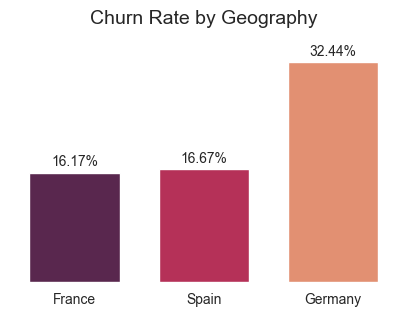

In [18]:
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='Geography', y='Exited', data=df, hue='Geography', 
palette='rocket', errorbar=None, dodge=False, width=0.7)

for container in ax.containers:
      ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Geography", fontsize=14, pad=20)
plt.show()
plt.show()

## Churn Rate by Credit Score

In [19]:
credit_score_churn = (df.groupby('CreditGroup')['Exited'].mean() * 100).round(2)
credit_score_churn.astype(str) + '%'

CreditGroup
Poor       32.28%
Average    20.99%
Good        19.8%
Name: Exited, dtype: str

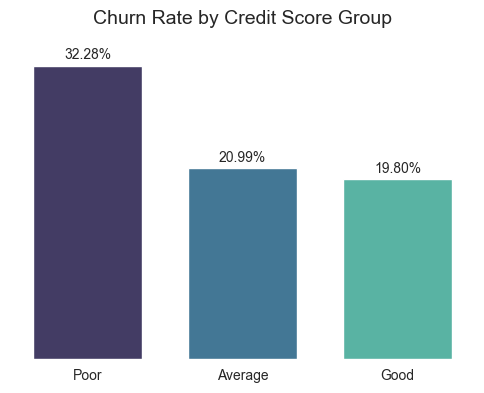

In [20]:
plt.figure(figsize=(6, 4))


ax = sns.barplot(x='CreditGroup', y='Exited', data=df, hue='CreditGroup', palette='mako', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Credit Score Group", fontsize=14, pad=20)
plt.show()


## Churn Rate by Card Type

In [21]:
card_type_churn = (df.groupby('Card Type')['Exited'].mean() * 100).round(2)
card_type_churn.astype(str) + '%'

Card Type
DIAMOND     21.78%
GOLD        19.26%
PLATINUM    20.36%
SILVER      20.11%
Name: Exited, dtype: str

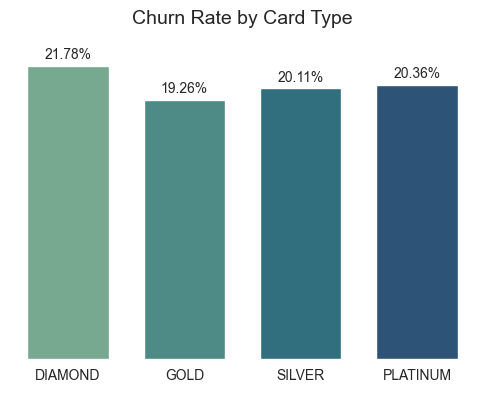

In [22]:
plt.figure(figsize=(6, 4))


ax = sns.barplot(x='Card Type', y='Exited', data=df, hue='Card Type', palette='crest', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Card Type", fontsize=14, pad=20)
plt.show()

## Satisfaction Score by Churn Rate

In [23]:
satisfaction_score = (df.groupby('Satisfaction Score')['Exited'].mean() * 100).round(2)
satisfaction_score.astype(str) + '%'

Satisfaction Score
1    20.03%
2     21.8%
3    19.64%
4    20.62%
5    19.81%
Name: Exited, dtype: str

## Churn Rate by Complaints

In [24]:
complaints = (df.groupby('Complain')['Exited'].mean() * 100).round(2)
complaints.astype(str) + '%'

Complain
0     0.05%
1    99.51%
Name: Exited, dtype: str

## Product Engagement vs Churn Rate

In [25]:
product = (df.groupby('NumOfProducts')['Exited'].mean() * 100).round(2)
product.astype(str) + '%'

NumOfProducts
1    27.71%
2      7.6%
3    82.71%
4    100.0%
Name: Exited, dtype: str

## Churn Rate VS Credit Card

In [26]:
credit_card = (df.groupby('HasCreditCard')['Exited'].mean() * 100).round(2)
credit_card.astype(str) + '%'

HasCreditCard
0    20.81%
1     20.2%
Name: Exited, dtype: str

## Churn Rate by Active Membership

In [27]:
active_membership = (df.groupby('IsActiveMember')['Exited'].mean() * 100).round(2)
active_membership.astype(str) + '%'

IsActiveMember
0    26.87%
1    14.27%
Name: Exited, dtype: str

## Churn Rate by Average Salary

In [28]:
average_salary = (df.groupby('EstimatedSalaryGroup')['Exited'].mean() * 100).round(2)
average_salary.astype(str) + '%'

EstimatedSalaryGroup
Low       19.93%
Medium    19.87%
High      20.23%
Name: Exited, dtype: str

## Churn Rate by Average Balance

In [29]:
average_balance = (df.groupby('BalanceGroup')['Exited'].mean() * 100).round(2)
average_balance.astype(str) + '%'


BalanceGroup
Low       14.25%
Medium    23.89%
High      24.05%
Name: Exited, dtype: str

## Churn Rate by Tenure

In [30]:
tenure = (df.groupby('TenureGroup')['Exited'].mean() * 100).round(2)
tenure.astype(str) + '%'    

TenureGroup
0-2     21.15%
3-5     20.76%
6-10    19.69%
Name: Exited, dtype: str

## Points Earned vs Churn Rate

In [31]:
point_earned = (df.groupby('PointGroup')['Exited'].mean()*100).round(2)
point_earned.astype(str) + '%'

PointGroup
Low       21.04%
Medium    19.86%
High       20.5%
Name: Exited, dtype: str

## Churn Risk Profile

In [32]:
risk_profile = (df.groupby(['IsActiveMember','Complain'])['Exited'].mean() * 100).round(2)
risk_profile.astype(str) + '%'

IsActiveMember  Complain
0               0            0.11%
                1           99.69%
1               0             0.0%
                1           99.19%
Name: Exited, dtype: str

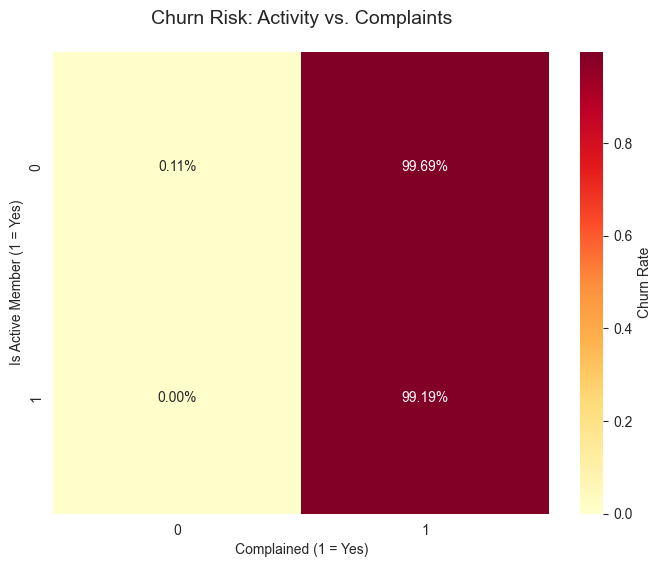

In [33]:
# Creating the pivot table based on my data
pivot_risk = df.groupby(['IsActiveMember', 'Complain'])['Exited'].mean().unstack()

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_risk, annot=True, fmt=".2%", cmap='YlOrRd', cbar_kws={'label': 'Churn Rate'})

plt.title('Churn Risk: Activity vs. Complaints', fontsize=14, pad=20)
plt.xlabel('Complained (1 = Yes)')
plt.ylabel('Is Active Member (1 = Yes)')
plt.show()

#  KPI Calculations
##  Overall Churn Rate

In [34]:
churn_rate = (df['Exited'].mean() * 100).round(2)
churn_rate.astype(str)
print(f"Overall churn rate = {churn_rate}{'%'}")

Overall churn rate = 20.38%


## % of Churned Customers with Complaints

In [35]:
churn_complaint = (df[df['Exited']==1]['Complain'].mean() * 100).round(2)
churn_complaint.astype(str)
print(f"% of Churned Customers with Complaints = {churn_complaint}{'%'}")

% of Churned Customers with Complaints = 99.8%


## Average Credit Score (Churned vs Retained)

In [36]:
df.groupby('Exited')['CreditScore'].mean()


Exited
0   652
1   645
Name: CreditScore, dtype: float64

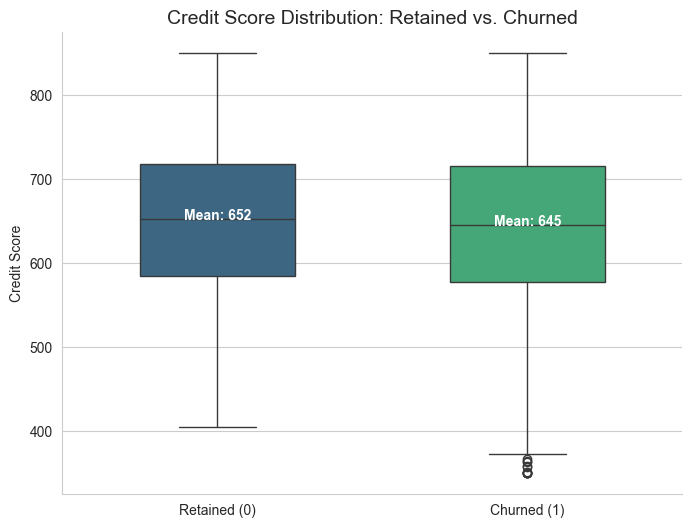

In [37]:
plt.figure(figsize=(8, 6))


ax = sns.boxplot(x='Exited', y='CreditScore', hue='Exited', data=df, palette='viridis', width=0.5, legend=False)


plt.text(0, 652, 'Mean: 652', color='white', ha='center', fontweight='bold')
plt.text(1, 645, 'Mean: 645', color='white', ha='center', fontweight='bold')

plt.title("Credit Score Distribution: Retained vs. Churned", fontsize=14)
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])
plt.ylabel("Credit Score")
plt.xlabel("")
sns.despine()

plt.show()

## Satisfaction score Distribution by churn status

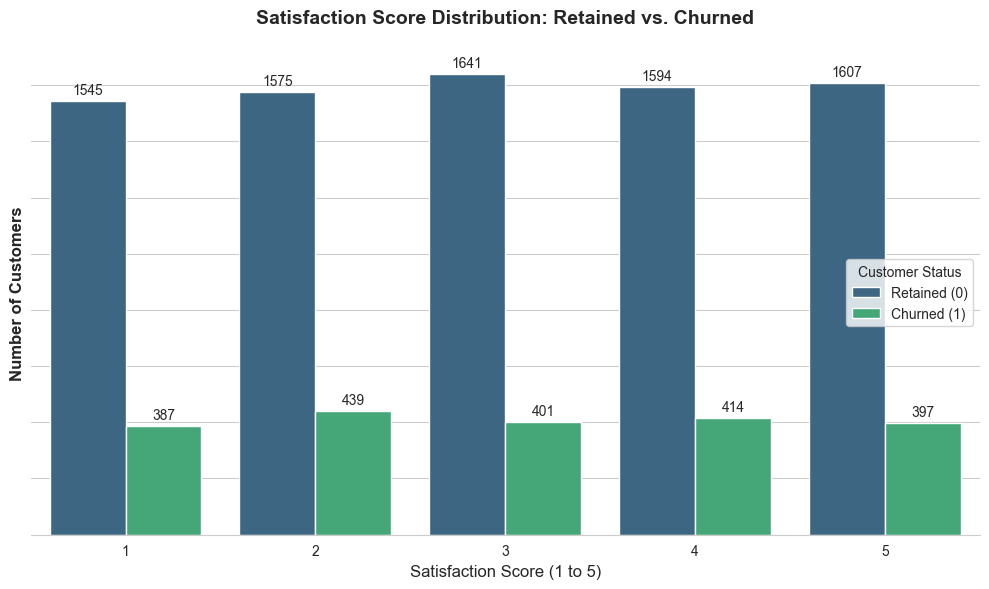

In [38]:
# Setting up the plotting canvas
plt.figure(figsize=(10, 6))

# Creating the countplot
ax = sns.countplot(data=df, x='Satisfaction Score', hue='Exited', palette='viridis')

# Add data labels directly on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)


ax.tick_params(left=False, labelleft=False)


ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')


sns.despine(left=True)


plt.title('Satisfaction Score Distribution: Retained vs. Churned', pad=20, fontsize=14, fontweight='bold')
plt.xlabel('Satisfaction Score (1 to 5)', fontsize=12)
plt.legend(title='Customer Status', labels=['Retained (0)', 'Churned (1)'])
plt.tight_layout()
plt.show()

## Tenure vs Churn Rate 

In [39]:
# Grouping by Tenure and calculating key metrics
tenure_analysis = df.groupby('Tenure')['Exited'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate=lambda x: round(x.mean() * 100, 2)
).reset_index()

# Displaying the final data frame
print(tenure_analysis)


    Tenure  Total_Customers  Churned_Customers  Churn_Rate
0        0              413                 95          23
1        1             1035                232          22
2        2             1048                201          19
3        3             1009                213          21
4        4              989                203          21
5        5             1012                209          21
6        6              967                196          20
7        7             1028                177          17
8        8             1025                197          19
9        9              984                214          22
10      10              490                101          21


## Product Holding and Churn Correlation 

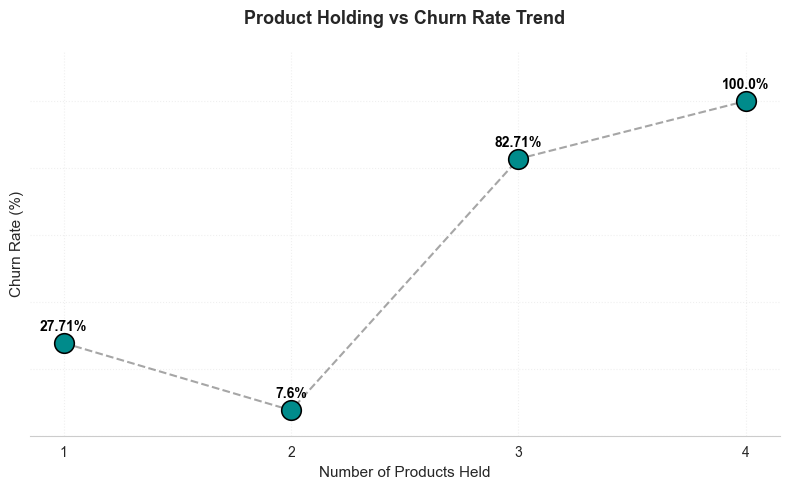

In [40]:

# Setting up the plotting canvas
plt.figure(figsize=(8, 5))

product_analysis = df.groupby('NumOfProducts')['Exited'].agg(
    Total_Customers='count',
    Churned_Customers='sum',
    Churn_Rate=lambda x: round(x.mean() * 100, 2)
).reset_index()

# Creating the scatter plot
ax = sns.scatterplot(
    data=product_analysis, 
    x='NumOfProducts', 
    y='Churn_Rate', 
    s=200, 
    color='darkcyan', 
    edgecolor='black', 
    zorder=3
)

# Connecting the scatter points with a line to visually trace the relationship
plt.plot(
    product_analysis['NumOfProducts'], 
    product_analysis['Churn_Rate'], 
    linestyle='--', 
    color='gray', 
    alpha=0.7, 
    zorder=2
)

# Step 1: Adding data labels directly above each scatter point
for idx, row in product_analysis.iterrows():
    ax.text(
        x=row['NumOfProducts'],
        y=row['Churn_Rate'] + 3,  
        s=f"{row['Churn_Rate']}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )


ax.tick_params(left=False, labelleft=False)
ax.set_ylabel('Churn Rate (%)', fontsize=11)

# Step 3: Giving the plot breathing room at the top so the 100% label does not get clipped
plt.ylim(0, 115)

# Clearing the left boundary line for a professional finish
sns.despine(left=True)

# Polishing presentation titles and labels
plt.title('Product Holding vs Churn Rate Trend', pad=20, fontsize=13, fontweight='bold')
plt.xlabel('Number of Products Held', fontsize=11)
plt.xticks(product_analysis['NumOfProducts'])
plt.grid(True, linestyle=':', alpha=0.3, zorder=1)
plt.tight_layout()

# Saving the updated image
plt.savefig('product_holding_churn_trend_labeled.png')
plt.show()

In [41]:
print(df.columns.tolist())

['RowNumber', 'CustomerId', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned', 'AgeGroup', 'TenureGroup', 'CreditGroup', 'BalanceGroup', 'EstimatedSalaryGroup', 'PointGroup']


# CHURN PREDICTION

## Prepping the Data for Scikit-Learn

In [42]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [43]:


# Step 1: Isolating the target variable we want to predict
y = df['Exited']

# Step 2: Selecting the features that carry predictive signal
# Dropping customer IDs, names, and the target column itself
feature_cols = ['CreditScore', 'Age', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'Satisfaction Score', 'Complain']
X = df[feature_cols]

# Step 3: The Split
# We hold back 20% of the data for the final exam (testing)
# random_state keeps the split identical every time you run it
# Corrected split line
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training the Algorithm(Random Forest)

In [44]:
# Initializin the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training the model (This is where the learning happens)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Testing

In [45]:
# Generating predictions
predictions = model.predict(X_test)

# Checking the baseline accuracy score
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")

# Printing the deeper diagnostic report
print(classification_report(y_test, predictions))

Model Accuracy: 99.85%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1592
           1       1.00      1.00      1.00       408

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



## Retraining the model with the best hyperparameters

In [46]:
# Step 1: Dropping the 'Complain' column to eliminate the data leakage
X_predictive = X.drop(columns=['Complain'])

# Step 2: Re-splitting the data using the exact same random state
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_predictive, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Initializing and training a new "clean" model
clean_model = RandomForestClassifier(n_estimators=100, random_state=42)
clean_model.fit(X_train_p, y_train_p)

# Step 4: Evaluating the clean model on unseen data
clean_predictions = clean_model.predict(X_test_p)
print(f"Clean Model Accuracy: {accuracy_score(y_test_p, clean_predictions):.2%}")
print(classification_report(y_test_p, clean_predictions))

Clean Model Accuracy: 85.30%
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1592
           1       0.72      0.46      0.56       408

    accuracy                           0.85      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



## Solving the 46% recall issue

In [47]:
# Initializing the model with the class_weight parameter set to balanced
weighted_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Training the new model on the exact same data
weighted_model.fit(X_train_p, y_train_p)

# Generating new predictions
weighted_predictions = weighted_model.predict(X_test_p)

# Evaluating the results
print(f"Weighted Model Accuracy: {accuracy_score(y_test_p, weighted_predictions):.2%}")
print(classification_report(y_test_p, weighted_predictions))

Weighted Model Accuracy: 85.35%
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1592
           1       0.73      0.45      0.55       408

    accuracy                           0.85      2000
   macro avg       0.80      0.70      0.73      2000
weighted avg       0.84      0.85      0.84      2000



## Threshold Adjustment Code

In [48]:
# Step 1: Getting the raw probabilities instead of hard 0 or 1 guesses
# This returns two columns: [Prob of staying, Prob of churning]
probabilities = clean_model.predict_proba(X_test_p)
churn_probabilities = probabilities[:, 1]

# Step 2: Set a custom threshold
# If the model thinks there is even a 35% chance they will leave, I flag them
custom_threshold = 0.35
threshold_predictions = (churn_probabilities >= custom_threshold).astype(int)

# Step 3: Evaluating the new strategy
print(f"Custom Threshold Accuracy: {accuracy_score(y_test_p, threshold_predictions):.2%}")
print(classification_report(y_test_p, threshold_predictions))

Custom Threshold Accuracy: 82.80%
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1592
           1       0.58      0.59      0.58       408

    accuracy                           0.83      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.83      0.83      0.83      2000



## Feature Importance

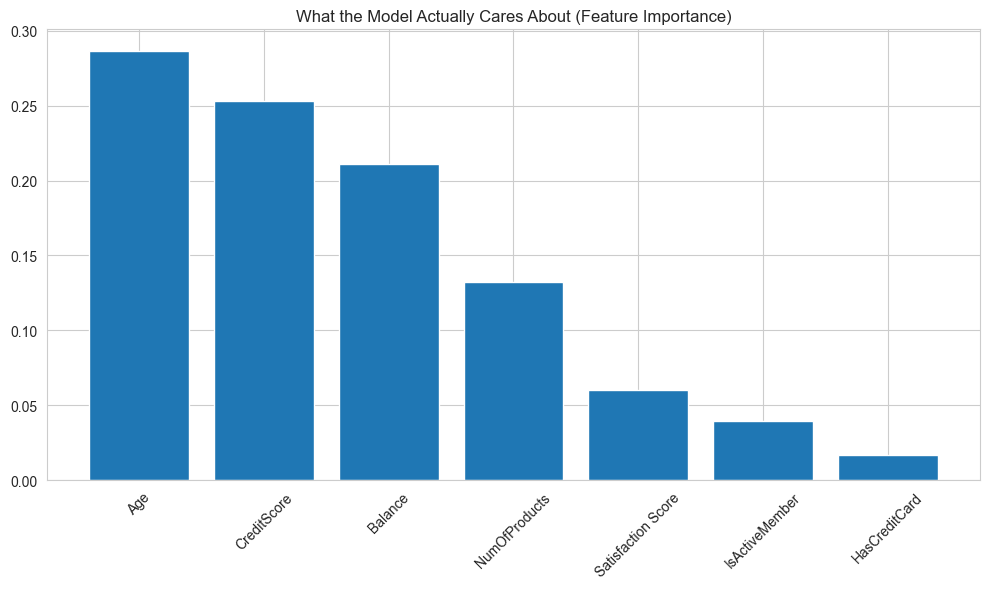

In [49]:

# Extracting feature importances from my clean model
importances = clean_model.feature_importances_
features = X_predictive.columns

# Sortting them in descending order
indices = np.argsort(importances)[::-1]

# Plotting the results
plt.figure(figsize=(10, 6))
plt.title("What the Model Actually Cares About (Feature Importance)")
plt.bar(range(X_predictive.shape[1]), importances[indices], align="center")
plt.xticks(range(X_predictive.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()

## ROC-AUC Score

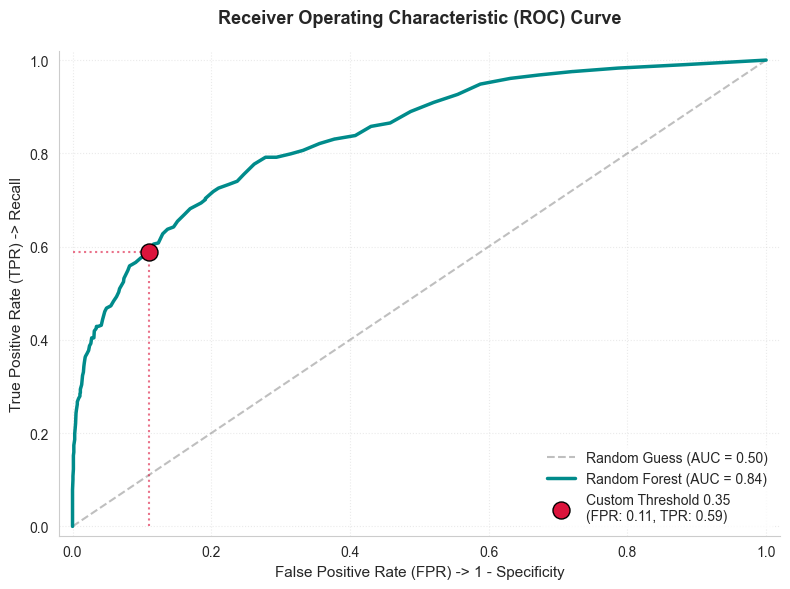

Exact Area Under the Curve (AUC) Score: 0.8385


In [50]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# Step 1: Generating the raw probabilities for the positive class (churn)
churn_probabilities = clean_model.predict_proba(X_test_p)[:, 1]

# Step 2: Calculating the global ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test_p, churn_probabilities)
auc_score = roc_auc_score(y_test_p, churn_probabilities)

# Step 3: Isolating the exact FPR and TPR for my custom 0.35 threshold
custom_preds = (churn_probabilities >= 0.35).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_p, custom_preds).ravel()
custom_tpr = tp / (tp + fn)
custom_fpr = fp / (fp + tn)

# Step 4: Plotting the ROC Curve using my minimalist design theme
plt.figure(figsize=(8, 6))

# Plotting the random guessing baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5, label='Random Guess (AUC = 0.50)')

# Plotting the actual model performance curve
plt.plot(fpr, tpr, color='darkcyan', linewidth=2.5, label=f'Random Forest (AUC = {auc_score:.2f})')

# Highlighting my 0.35 threshold point on the curve
plt.scatter(custom_fpr, custom_tpr, color='crimson', s=150, edgecolor='black', zorder=5, 
            label=f'Custom Threshold 0.35\n(FPR: {custom_fpr:.2f}, TPR: {custom_tpr:.2f})')

# Adding a visual guide line to my custom point
plt.vlines(custom_fpr, 0, custom_tpr, colors='crimson', linestyles=':', alpha=0.6)
plt.hlines(custom_tpr, 0, custom_fpr, colors='crimson', linestyles=':', alpha=0.6)

# Chart styling and polish
plt.title('Receiver Operating Characteristic (ROC) Curve', pad=20, fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate (FPR) -> 1 - Specificity', fontsize=11)
plt.ylabel('True Positive Rate (TPR) -> Recall', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')

# Cleaning layout display
import seaborn as sns
sns.despine()
plt.tight_layout()
plt.savefig('model_roc_auc_curve.png')
plt.show()

print(f"Exact Area Under the Curve (AUC) Score: {auc_score:.4f}")

## Saving the file for export to Power Bi for Visualization

In [55]:
bi_export_df = X_test_p.copy()

# 2. Re-attaching the actual target labels for historical tracking
bi_export_df['Actual_Churn'] = y_test_p

# 3. Pulling the continuous probability scores from my Random Forest model
bi_export_df['Churn_Probability'] = clean_model.predict_proba(X_test_p)[:, 1]

# 4. Generating the binary classification flags based on my 0.35 threshold
bi_export_df['Predicted_Churn'] = (bi_export_df['Churn_Probability'] >= 0.35).astype(int)

# 5. Creating clear text labels for the risk segments to simplify Power BI filtering
bi_export_df['Churn_Risk_Group'] = bi_export_df['Predicted_Churn'].map({1: 'High Risk', 0: 'Low Risk'})
bi_export_df['Actual_Status'] = bi_export_df['Actual_Churn'].map({1: 'Left Bank', 0: 'Stayed'})


columns_to_bring_back = [
    'CustomerId', 
    'Geography', 
    'Gender', 
    'Point Earned', 
    'Tenure', 
    'Satisfaction Score', 
    'Card Type', 
    'Complain'
]

bi_export_df = bi_export_df.merge(df[columns_to_bring_back], left_index=True, right_index=True)

# 7. Writing the comprehensive, secure dataset to a CSV file
bi_export_df.to_csv('bank_churn_scored_secure.csv', index=False)
print("Complete dashboard dataset successfully generated and saved as 'bank_churn_scored_secure.csv'!")

Complete dashboard dataset successfully generated and saved as 'bank_churn_scored_secure.csv'!
